<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/04_MLP_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
from pathlib import Path

import json
import random
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Flatten,
    Dense,
    Dropout,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
drive.mount("/content/drive")

Mounted at /content/drive


In [26]:
LOOKBACK_DAYS = 14

In [27]:
shared_project_dir = Path(
    "/content/drive/MyDrive/Quant Research"
)

btc_data_dir = (
    shared_project_dir
    / "data"
    / "model_ready"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
)

results_dir = (
    shared_project_dir
    / "results"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
    / "MLP"
)

models_dir = (
    shared_project_dir
    / "models"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
    / "MLP"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [28]:
X_train = np.load(
    btc_data_dir / "X_train_scaled.npy"
)

X_val = np.load(
    btc_data_dir / "X_val_scaled.npy"
)

y_train = np.load(
    btc_data_dir / "y_train.npy"
)

y_val = np.load(
    btc_data_dir / "y_val.npy"
)

validation_metadata = pd.read_parquet(
    btc_data_dir
    / "validation_metadata.parquet"
)

with open(
    btc_data_dir / "dataset_configuration.json",
    "r",
    encoding="utf-8"
) as file:
    configuration = json.load(file)

In [29]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_train.shape[1:] == X_val.shape[1:]
assert len(validation_metadata) == len(y_val)

X_train: (1527, 14, 7)
X_val: (365, 14, 7)
y_train: (1527,)
y_val: (365,)


In [30]:
def build_mlp_model(
    lookback_days,
    n_features
):
    model = Sequential(
        [
            Input(
                shape=(
                    lookback_days,
                    n_features
                )
            ),

            Flatten(),

            Dense(
                units=64,
                activation="relu"
            ),

            Dropout(rate=0.20),

            Dense(
                units=32,
                activation="relu"
            ),

            Dropout(rate=0.10),

            Dense(
                units=1,
                activation="linear"
            ),
        ],
        name="btc_mlp_log_rv"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

In [31]:
LOOKBACK_DAYS = X_train.shape[1]
N_FEATURES = X_train.shape[2]

mlp_model = build_mlp_model(
    lookback_days=LOOKBACK_DAYS,
    n_features=N_FEATURES
)

mlp_model.summary()

Model: "btc_mlp_log_rv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 98)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,449 (33.00 KB)

 Trainable params: 8,449 (33.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
best_model_path = (
    models_dir
    / "best_mlp_model.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
]

In [33]:
history = mlp_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=200,
    batch_size=32,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
41/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 42.0561 - mae: 6.2435
Epoch 1: val_loss improved from None to 12.28731, saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_14d/MLP/best_mlp_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_14d/MLP/best_mlp_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 35.1541 - mae: 5.6215 - val_loss: 12.2873 - val_mae: 3.2554 - learning_rate: 0.0010
Epoch 2/200
38/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.0061 - mae: 3.3089
Epoch 2: val_loss improved from 12.28731 to 5.17121, saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_14d/MLP/best_mlp_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_14d/MLP/best_mlp_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.7032 - mae: 2.7087 - val_loss: 5.1712 - val_mae: 1.9249 - learning_rate: 0.0010
Epoch 3

In [34]:
history_df = pd.DataFrame(
    history.history
)

history_df["epoch"] = (
    np.arange(len(history_df)) + 1
)

history_df.head()

,loss,mae,val_loss,val_mae,learning_rate,epoch
0,35.154118,5.621469,12.287313,3.255448,0.001,1
1,10.703223,2.708749,5.171212,1.924899,0.001,2
2,6.515059,2.141135,2.524743,1.281382,0.001,3
3,4.431311,1.723225,1.745910,1.051320,0.001,4
4,3.563385,1.528164,1.290356,0.903489,0.001,5


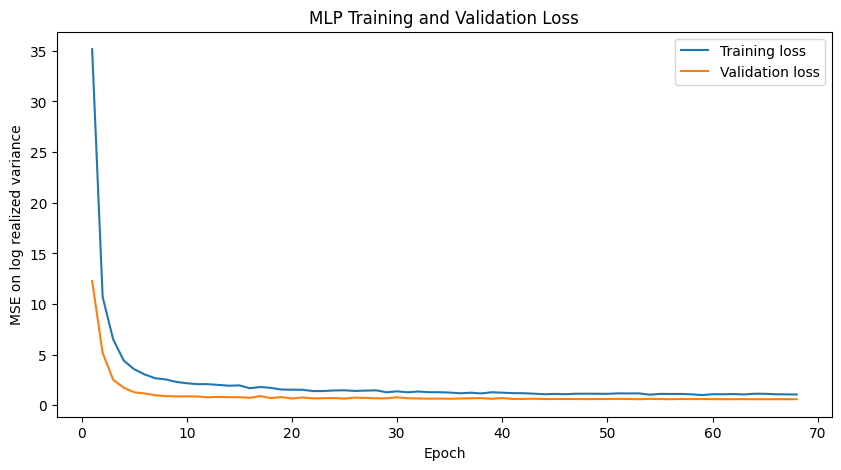

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["loss"],
    label="Training loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE on log realized variance")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.show()

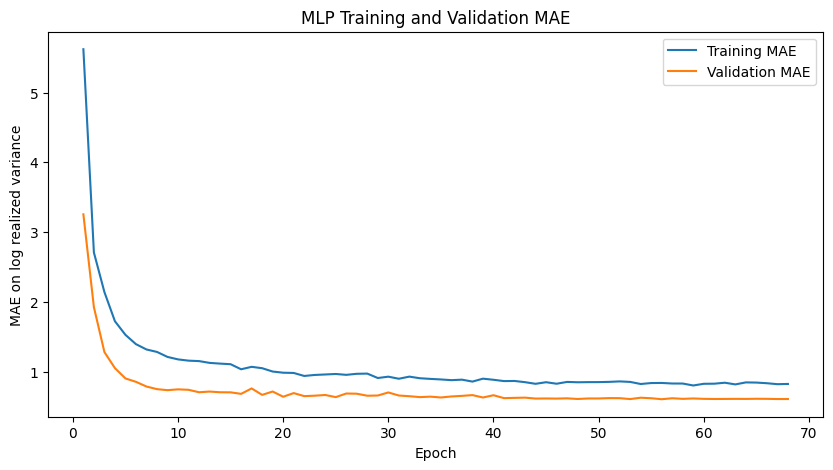

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["mae"],
    label="Training MAE"
)

plt.plot(
    history_df["epoch"],
    history_df["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE on log realized variance")
plt.title("MLP Training and Validation MAE")
plt.legend()
plt.show()

In [37]:
mlp_pred_log_rv = (
    mlp_model.predict(
        X_val,
        batch_size=32,
        verbose=0
    )
    .reshape(-1)
)

In [38]:
mlp_pred_rv = np.exp(
    mlp_pred_log_rv
)

actual_log_rv = y_val

actual_rv = validation_metadata[
    "actual_rv"
].to_numpy()

In [39]:
assert len(mlp_pred_rv) == len(actual_rv)
assert np.isfinite(mlp_pred_log_rv).all()
assert np.isfinite(mlp_pred_rv).all()
assert (mlp_pred_rv > 0).all()

print("Prediction checks passed.")

Prediction checks passed.


In [40]:
def mean_absolute_error(
    y_true,
    y_pred
):
    return np.mean(
        np.abs(
            np.asarray(y_true)
            - np.asarray(y_pred)
        )
    )


def root_mean_squared_error(
    y_true,
    y_pred
):
    return np.sqrt(
        np.mean(
            (
                np.asarray(y_true)
                - np.asarray(y_pred)
            ) ** 2
        )
    )


def qlike(
    y_true,
    y_pred,
    epsilon=1e-12
):
    y_true = np.maximum(
        np.asarray(y_true),
        epsilon
    )

    y_pred = np.maximum(
        np.asarray(y_pred),
        epsilon
    )

    ratio = y_true / y_pred

    return np.mean(
        ratio
        - np.log(ratio)
        - 1
    )


def evaluate_forecast(
    model_name,
    y_true,
    y_pred
):
    return {
        "model": model_name,
        "mae": mean_absolute_error(
            y_true,
            y_pred
        ),
        "rmse": root_mean_squared_error(
            y_true,
            y_pred
        ),
        "qlike": qlike(
            y_true,
            y_pred
        ),
    }

In [41]:
model_name=f"MLP-{LOOKBACK_DAYS}d"

mlp_result = evaluate_forecast(
    model_name=model_name,
    y_true=actual_rv,
    y_pred=mlp_pred_rv
)

mlp_result

{'model': 'MLP-14d',
 'mae': np.float64(0.00044155933333981057),
 'rmse': np.float64(0.0009071963576972457),
 'qlike': np.float64(0.35486087385198356)}

In [42]:
baseline_metrics_path = (
    shared_project_dir
    / "results"
    / "BTCUSDT"
    / "baseline_validation_metrics.csv"
)

baseline_results_df = pd.read_csv(
    baseline_metrics_path
)

In [43]:
comparison_df = pd.concat(
    [
        baseline_results_df,
        pd.DataFrame([mlp_result])
    ],
    ignore_index=True
)

comparison_df = (
    comparison_df
    .sort_values("qlike")
    .reset_index(drop=True)
)

comparison_df

,model,mae,rmse,qlike
0,7-Day Mean RV,0.000455,0.000899,0.343857
1,MLP-14d,0.000442,0.000907,0.354861
2,30-Day Mean RV,0.000483,0.000921,0.399752
3,Persistence,0.000514,0.001087,0.464700


In [44]:
mlp_predictions_df = (
    validation_metadata[
        [
            "symbol",
            "sequence_start_date",
            "sequence_end_date",
            "target_date",
            "actual_rv",
        ]
    ]
    .copy()
)

mlp_predictions_df[
    "actual_log_rv"
] = y_val

mlp_predictions_df[
    "mlp_pred_log_rv"
] = mlp_pred_log_rv

mlp_predictions_df[
    "mlp_pred_rv"
] = mlp_pred_rv

In [45]:
history_df.to_csv(
    results_dir
    / "mlp_training_history.csv",
    index=False
)

pd.DataFrame([mlp_result]).to_csv(
    results_dir
    / "mlp_validation_metrics.csv",
    index=False
)

comparison_df.to_csv(
    results_dir
    / "mlp_baseline_comparison.csv",
    index=False
)

mlp_predictions_df.to_parquet(
    results_dir
    / "mlp_validation_predictions.parquet",
    index=False
)

mlp_model.save(
    models_dir
    / "final_mlp_model.keras"
)

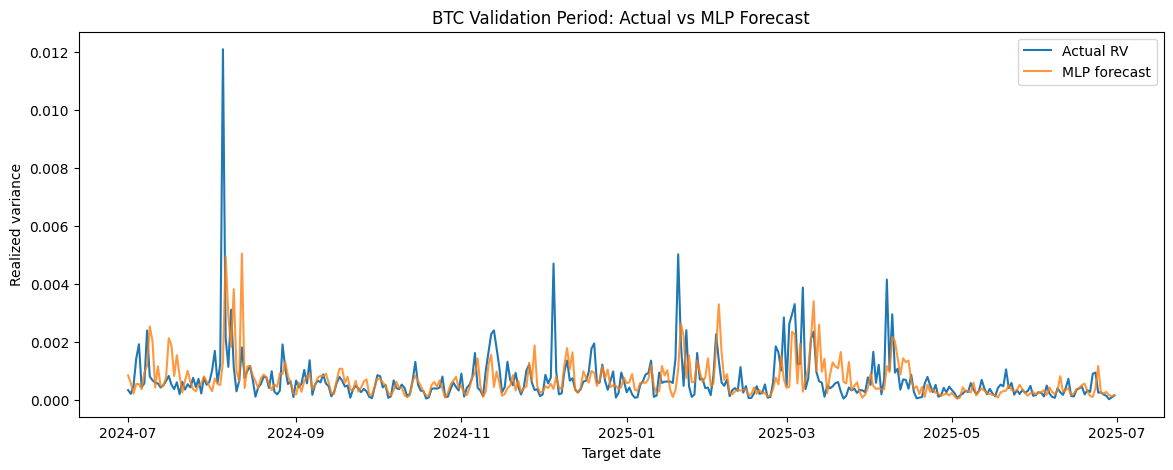

In [46]:
plt.figure(figsize=(14, 5))

plt.plot(
    mlp_predictions_df["target_date"],
    mlp_predictions_df["actual_rv"],
    label="Actual RV"
)

plt.plot(
    mlp_predictions_df["target_date"],
    mlp_predictions_df["mlp_pred_rv"],
    label="MLP forecast",
    alpha=0.8
)

plt.xlabel("Target date")
plt.ylabel("Realized variance")
plt.title(
    "BTC Validation Period: "
    "Actual vs MLP Forecast"
)

plt.legend()
plt.show()

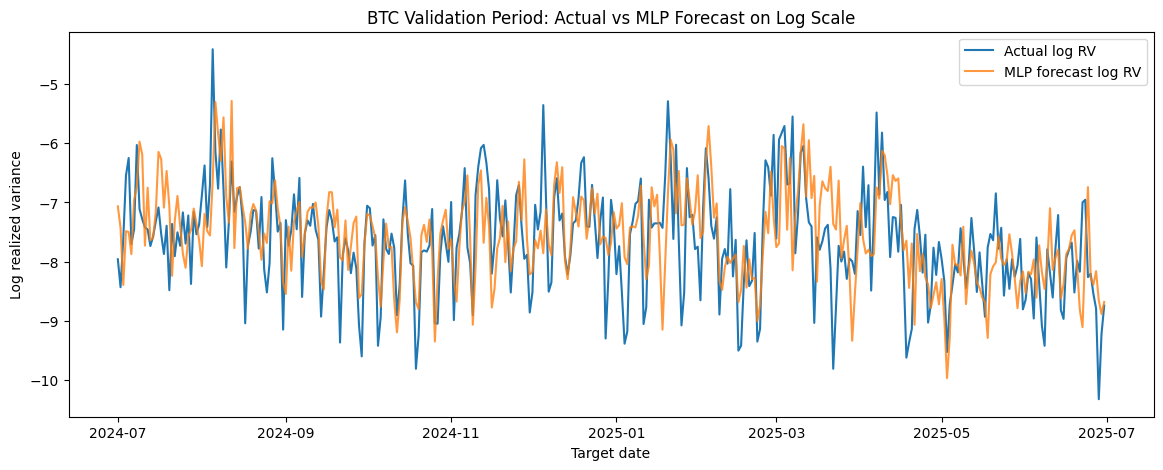

In [47]:
plt.figure(figsize=(14, 5))

plt.plot(
    mlp_predictions_df["target_date"],
    mlp_predictions_df["actual_log_rv"],
    label="Actual log RV"
)

plt.plot(
    mlp_predictions_df["target_date"],
    mlp_predictions_df["mlp_pred_log_rv"],
    label="MLP forecast log RV",
    alpha=0.8
)

plt.xlabel("Target date")
plt.ylabel("Log realized variance")
plt.title(
    "BTC Validation Period: "
    "Actual vs MLP Forecast on Log Scale"
)

plt.legend()
plt.show()